In [27]:
import pandas as pd
import seaborn as sns
import matplotlib as plt

In [28]:
data = pd.read_excel("df.xlsx")
data.head()

,Date,Year,Season,Sown_Extent_Major,Sown_Extent_Minor,Sown_Extent_Rainfall,Sown_Extent_Total,Harvested_Extent_Major,Harvested_Extent_Minor,Harvested_Extent_Rainfall,...,Fung_Used,Fung_NotUsed,Short_Grain_Red,Long_Grain_Red,Short_Grain_White,Long_Grain_White,Other(seed_variety),New_Improved,Old_Improved,Traditional
0,1978-09-01,1979,Maha,0,0,0,578068,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1979-04-01,1979,Yala,0,0,0,260557,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1979-09-01,1980,Maha,0,0,0,573434,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1980-04-01,1980,Yala,0,0,0,271212,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1980-09-01,1981,Maha,0,0,0,596692,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
df = data.iloc[27:,:]
df.head()

,Date,Year,Season,Sown_Extent_Major,Sown_Extent_Minor,Sown_Extent_Rainfall,Sown_Extent_Total,Harvested_Extent_Major,Harvested_Extent_Minor,Harvested_Extent_Rainfall,...,Fung_Used,Fung_NotUsed,Short_Grain_Red,Long_Grain_Red,Short_Grain_White,Long_Grain_White,Other(seed_variety),New_Improved,Old_Improved,Traditional
27,1992-04-01,1992,Yala,130502,49825,74657,254983,122937,47463,72833,...,24.10,75.90,0.0,0.0,0.0,0.0,0.0,90.55,0.81,8.64
28,1992-09-01,1993,Maha,247069,130475,168145,545689,245058,127580,165398,...,24.32,75.68,0.0,0.0,0.0,0.0,0.0,89.89,1.43,8.68
29,1993-04-01,1993,Yala,162398,45118,81088,288605,160944,43231,77531,...,18.27,81.73,0.0,0.0,0.0,0.0,0.0,90.25,1.12,8.63
30,1993-09-01,1994,Maha,262421,149356,169287,581064,250482,145815,164396,...,23.46,76.54,0.0,0.0,0.0,0.0,0.0,87.39,3.44,9.17
31,1994-04-01,1994,Yala,207466,63284,77806,348556,206527,58869,70462,...,19.81,80.19,0.0,0.0,0.0,0.0,0.0,92.78,1.28,5.93


In [30]:
# Sort chronologically
df = df.sort_values('Date')

In [31]:
type(df)

pandas.DataFrame

In [32]:
df.set_index('Date', inplace=True)
df.head(3)


,Year,Season,Sown_Extent_Major,Sown_Extent_Minor,Sown_Extent_Rainfall,Sown_Extent_Total,Harvested_Extent_Major,Harvested_Extent_Minor,Harvested_Extent_Rainfall,Harvested_Extent_Total,...,Fung_Used,Fung_NotUsed,Short_Grain_Red,Long_Grain_Red,Short_Grain_White,Long_Grain_White,Other(seed_variety),New_Improved,Old_Improved,Traditional
Date,,,,,,,,,,,,,,,,,,,,,
1992-04-01,1992,Yala,130502,49825,74657,254983,122937,47463,72833,243236,...,24.10,75.90,0.0,0.0,0.0,0.0,0.0,90.55,0.81,8.64
1992-09-01,1993,Maha,247069,130475,168145,545689,245058,127580,165398,538060,...,24.32,75.68,0.0,0.0,0.0,0.0,0.0,89.89,1.43,8.68
1993-04-01,1993,Yala,162398,45118,81088,288605,160944,43231,77531,281706,...,18.27,81.73,0.0,0.0,0.0,0.0,0.0,90.25,1.12,8.63


In [33]:
ts1 = df['Production']


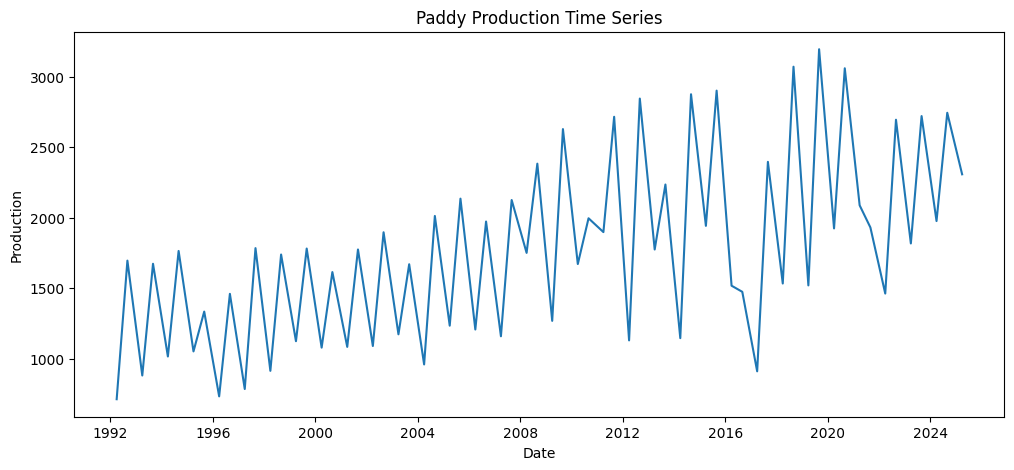

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(ts1)

plt.title("Paddy Production Time Series")
plt.xlabel("Date")
plt.ylabel("Production")

plt.show()

In [35]:
train_size = int(len(ts1) * 0.8)

train = ts1.iloc[:train_size]
test = ts1.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 53
Test size: 14


In [36]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Stationary")
else:
    print("Not stationary")

ADF Statistic: -0.9879472177551676
p-value: 0.7576348536448954
Not stationary


NameError: name 'plot_acf' is not defined

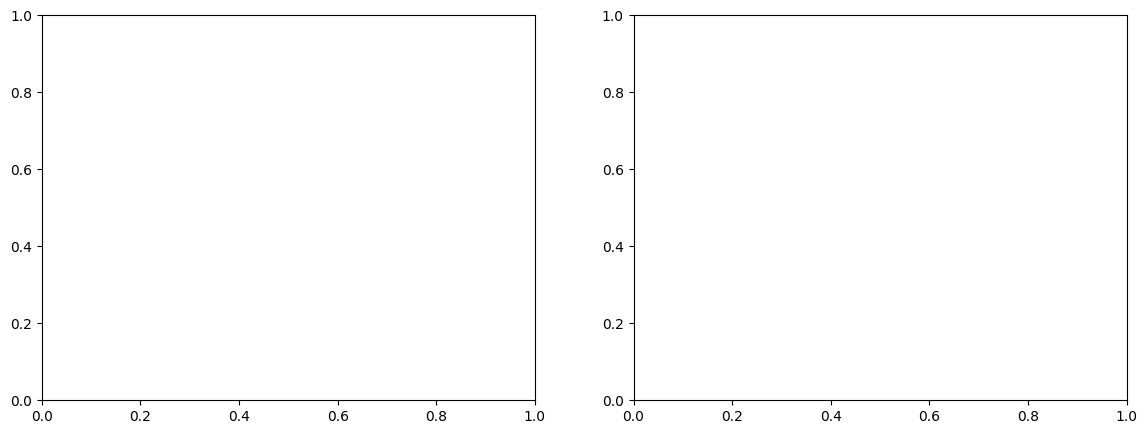

In [37]:
# plots
fig, axes = plt.subplots(1,2, figsize=(14,5))

plot_acf(ts1, lags=10, ax=axes[0])

plot_pacf(ts1, lags=10, ax=axes[1])

plt.show()

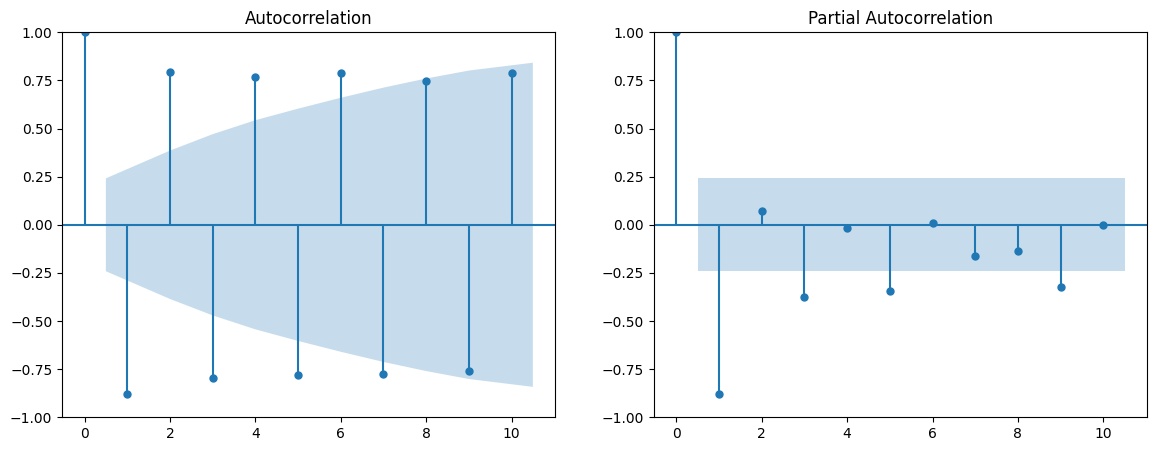

In [38]:
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# differencing
ts_diff = ts1.diff().dropna()

# plots
fig, axes = plt.subplots(1,2, figsize=(14,5))

plot_acf(ts_diff, lags=10, ax=axes[0])

plot_pacf(ts_diff, lags=10, ax=axes[1])

plt.show()

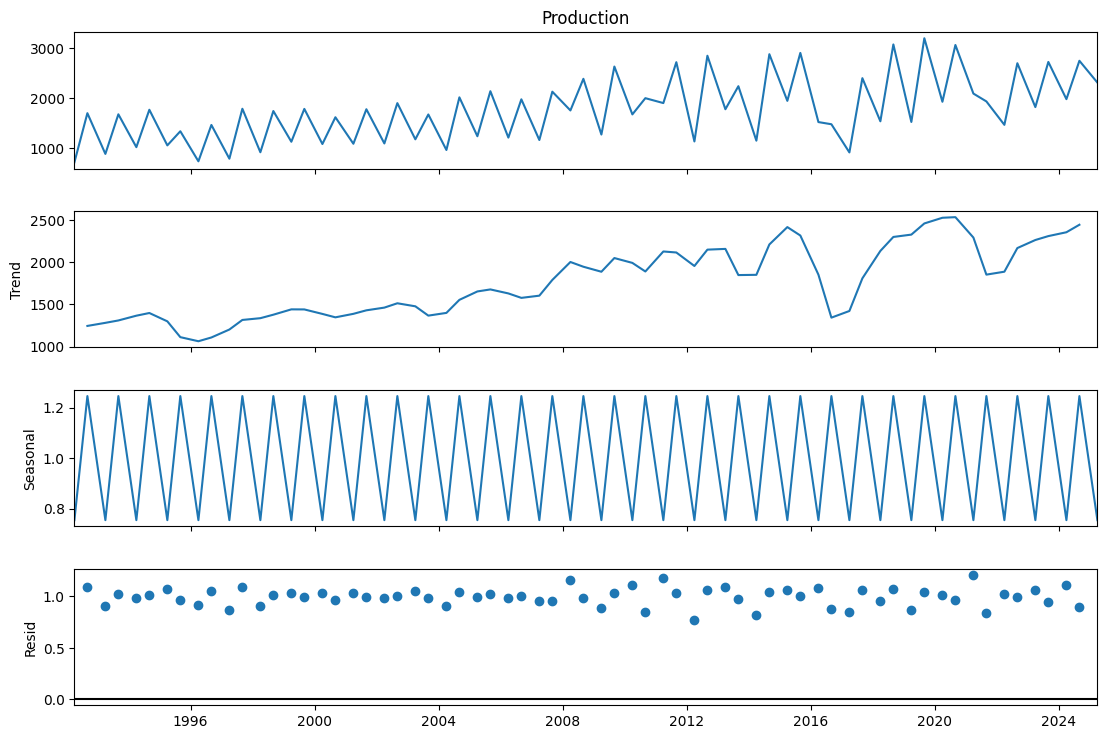

Date
1992-04-01         NaN
1992-09-01    1.092495
1993-04-01    0.910159
1993-09-01    1.024843
1994-04-01    0.984807
                ...   
2023-04-01    1.065116
2023-09-01    0.945865
2024-04-01    1.113178
2024-09-01    0.901503
2025-04-01         NaN
Name: resid, Length: 67, dtype: float64

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(
    ts1,
    model='multiplicative',
    period=2
)

fig = decomposition.plot()

fig.set_size_inches(12, 8)

plt.show()
residuals     = decomposition.resid
residuals

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    # order=(1,1,1),
    # seasonal_order=(1,1,1,2)
     order=(0,0,1),
    seasonal_order=(0,1,1,2)
)

model_fit = model.fit()

print(model_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                        Production   No. Observations:                   53
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 2)   Log Likelihood                -364.588
Date:                           Sat, 16 May 2026   AIC                            735.175
Time:                                   10:09:36   BIC                            740.971
Sample:                                        0   HQIC                           737.390
                                            - 53                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.5754      0.244      2.355      0.019       0.097       1.054
ma.S.L2       -0.7067      0.139     -5.095

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


******************************************************************************************************************************************************
******************************************************************************************************************************************************

In [39]:
# pip install pmdarima

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

#load dataset
data = pd.read_excel("df.xlsx")
df = data.iloc[27:,:] # from 1992-2025


df.set_index('Date', inplace=True)
df = df.sort_values('Date')

# Optional but recommended
#df = df.asfreq('6MS')

ts = df['Production']

# train / test split
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]


In [ ]:
# # Automatically Find Best SARIMA Model
# auto_model = auto_arima(
#     train,

#     seasonal=True,
#     m=2,                 # Yala + Maha cycle

#     start_p=0,
#     start_q=0,
#     max_p=3,
#     max_q=3,
    

#     start_P=0,
#     start_Q=0,
#     max_P=2,
#     max_Q=2,

#     d=None,
#     D=None,

#     trace=True,
#     error_action='ignore',
#     suppress_warnings=True,
#     stepwise=True
# )

# print(auto_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                   53
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 2)   Log Likelihood                -362.661
Date:                           Sat, 16 May 2026   AIC                            733.322
Time:                                   10:10:40   BIC                            741.049
Sample:                                        0   HQIC                           736.275
                                            - 53                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     35.2591     15.025      2.347      0.019       5.811      64.708
ma.L1          0.4345      0.184      2.367

In [40]:
from pmdarima import auto_arima

# Fit the model
auto_model = auto_arima(train, 
                   seasonal=True, 
                   m=2, 
                   stepwise=True, 
                   suppress_warnings=True)


# Generate a summary of the best model found
print(auto_model.summary())

# # Make forecasts
# forecast = auto_model.predict(n_periods=10)

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                   53
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 2)   Log Likelihood                -362.661
Date:                           Mon, 18 May 2026   AIC                            733.322
Time:                                   11:00:22   BIC                            741.049
Sample:                                        0   HQIC                           736.275
                                            - 53                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     35.2591     15.025      2.347      0.019       5.811      64.708
ma.L1          0.4345      0.184      2.367

In [41]:
#Extract Best Parameters
print("Best Model Order:", auto_model.order)

print("Best Seasonal Order:", auto_model.seasonal_order)

Best Model Order: (0, 0, 1)
Best Seasonal Order: (0, 1, 1, 2)


In [ ]:
#Fit Final SARIMA Model
# model = SARIMAX(
#     train,
#     order=auto_model.order,
#     seasonal_order=auto_model.seasonal_order
# )

# model_fit = model.fit()

# print(model_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                        Production   No. Observations:                   53
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 2)   Log Likelihood                -364.588
Date:                           Sat, 16 May 2026   AIC                            735.175
Time:                                   10:13:31   BIC                            740.971
Sample:                                        0   HQIC                           737.390
                                            - 53                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.5754      0.244      2.355      0.019       0.097       1.054
ma.S.L2       -0.7067      0.139     -5.095

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [44]:
#Forecast
forecast1 = auto_model.predict(steps=len(test))
forecast1

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


53    2495.565291
54    1631.225599
55    2561.673592
56    1666.484654
57    2596.932647
58    1701.743709
59    2632.191702
60    1737.002765
61    2667.450757
62    1772.261820
dtype: float64

In [ ]:
#Evaluate Model
rmse = np.sqrt(mean_squared_error(test, forecast))

print("RMSE:", rmse)

RMSE: 552.3570460171596


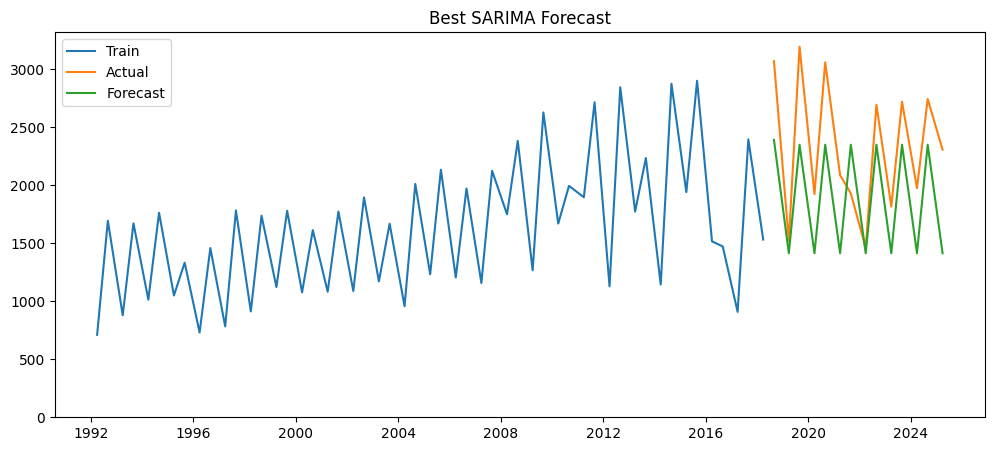

In [ ]:
#Plot Forecast
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label='Train')

plt.plot(test.index, test, label='Actual')

plt.plot(test.index, forecast, label='Forecast')

plt.legend()

plt.title("Best SARIMA Forecast")

plt.ylim(0,)

plt.show()